Copyright @2025 Maria Babakhanyan Stone

# Light-GG
# Memory saving algorithm to create a coordinate system (2D), but with human-intuitive inputs

# Example of 3x3 sky grid!

In [1]:
#import the necessary packages

#for working with array data
import numpy as np

# for astronomy considerations
from astropy import units as u # to have units
from astropy.coordinates import SkyCoord, Angle # to work with coordinates
from astropy.table import Table # for tables

# LightGG functions
from functions_LightGG import LightGG_catalog, plot_LightGG


Create a coordinate grid

Let's make a 3x3 grid first.

In [2]:
# We use units of angles

delta_angle = 2 # units in arcseconds

x_reference = 0 # units in arcseconds
y_reference = 0 # units in arcseconds

In [3]:
# Calculate start and End from reference point

end_x = x_reference + delta_angle
end_y = y_reference + delta_angle

In [4]:
# Number of points, we do the same for a square grid
# For 1 arcsecond resolution, we input the number of arcseconds in a degree

N = delta_angle+1 # * 60 * 60 # number of points is the number of arcseconds
N_points_x = N
N_points_y = N

In [5]:
# creating the axes with evenly spaced coordinate spots

vector_x = np.linspace (x_reference, end_x, N_points_x)
vector_y = np.linspace (y_reference, end_y, N_points_y)

In [6]:
# Use broadcasting to mimic the behaviour of a grid, without actually making a 2D Numpy Grid

In [7]:
N_tiles = N*N
print('The total number of tiles is ',N_tiles)

The total number of tiles is  9


In [8]:
vector_x

array([0., 1., 2.])

In [9]:
vector_y[:3]

array([0., 1., 2.])

Now, create ra and dec instances for each coordinates in the grid.
For that we use the np.tile and np.repeat methods.

In [10]:
tiled_vector_x = np.tile(vector_x,N_points_y)

In [11]:
tiled_vector_x

array([0., 1., 2., 0., 1., 2., 0., 1., 2.])

In [12]:
repeated_vector_y = np.repeat(vector_y,N_points_x)

In [13]:
repeated_vector_y

array([0., 0., 0., 1., 1., 1., 2., 2., 2.])

In [14]:
print('RA appears ',len(tiled_vector_x),' times and Dec also ',len(repeated_vector_y), '  . ')

RA appears  9  times and Dec also  9   . 


Pairwise matching them will create coordinate pairs
for each grid vertex (point).

Let's build the SkyCoord object now

In [15]:
# We need the RA and Dec values, and let's make them in arcseconds.

SkyCoord_RA_1D = np.copy(tiled_vector_x)*u.arcsec
SkyCoord_Dec_1D = np.copy(repeated_vector_y)*u.arcsec

In [16]:
# Now create the sky model, or the grid model
# I repeat the units to be clear!

sky_model = SkyCoord(ra=SkyCoord_RA_1D, dec = SkyCoord_Dec_1D, unit=u.deg)

### make a table output of the grid
We convert the SkyCoord into an Astropy Table and save it as FITS

In [18]:
skymodel_table = LightGG_catalog(sky_model, 'sky_3x3grid.fits', u.arcsec)    

In [26]:
# Write up the function to generalize the 3x3 to NxN
# Use human-intuitive inputs, safe defaults, and clear steps

def make_LightGG(ra_reference, dec_reference, 
                 delta_ra, delta_dec,
                 max_points=5e7,
                ):
    
    """
    Create a rectangular sky grid and return a SkyCoord object.
    
    Parameters:
    -----------
    reference_ra, reference_dec : float
        Reference point coordinates for the coordinaty system. Units of arcseconds. These are absolute coordinates.
    delta_ra, delta_dec: float
        Interval extent from reference point along each axis. Units of arcseconds. These are extents, not angular separations on the sphere.
    max_points : int
        Safety limit to avoid accidental memory exhaustion.
        
    Returns
    -------
    skycoord : astropy.coordinates.SkyCoord
        Flattened grid of sky coordinates.
    
    """


    # Calculate the number of points ( 1 arcsecond resolution)
    N_points_ra = int(delta_ra) + 1
    N_points_dec = int(delta_dec) + 1


    n_total = N_points_ra * N_points_dec
    if n_total > max_points:
        raise MemoryError(
            f"Grid has {n_total:.2e} points; exceeds limit {max_points:.2e}")

    # Calculate the end-points
    ra_end = ra_reference + delta_ra
    dec_end = dec_reference + delta_dec


    # 1D axes (human-intuitive)
    ra_axis = np.linspace(ra_reference, ra_end, N_points_ra)
    dec_axis = np.linspace(dec_reference, dec_end, N_points_dec)

    # Flattened grid (no 2D intermediate arrays)
    tiled_vector_ra = np.tile(ra_axis, N_points_dec)
    repeated_vector_dec = np.repeat (dec_axis, N_points_ra)


    # SkyCoord catalog. Pairwise matching the above vectors.

    ## We first explicitely write out what is input into the SkyCoord for clarity, in arcsecond unit for each coordinate vertex in the grid

    SkyCoord_RA_1D = np.copy(tiled_vector_ra)*u.arcsec
    SkyCoord_Dec_1D = np.copy(repeated_vector_dec)*u.arcsec


    ## Now we create the sky model or the grid model.
    ## I repeat the units, to be clear
    ## I explicitely state the frame, even though it is the default value, for clarity.

    LightGG_model = SkyCoord(
        ra = SkyCoord_RA_1D,
        dec = SkyCoord_Dec_1D,
        frame = "icrs",
        unit = u.arcsec)

    return LightGG_model




In [27]:
# Example use (1 degree by 1 degree, 1'' resolution)

N = 3600

sky_gridmodel_1sqdeg_patch = make_LightGG (
    ra_reference = 0.0,
    dec_reference = 0.0,
    delta_ra = 1.0,
    delta_dec= 1.0
)




In [28]:
import matplotlib.pyplot as plt

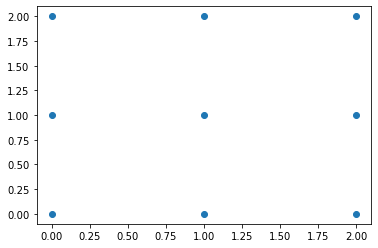

In [35]:
plt.scatter(sky_model.ra.to(u.arcsec).value, sky_model.dec.to(u.arcsec).value)



Example use of the plotting function

In [36]:
plot_LightGG(sky_model)

NameError: name 'plot_LightGG' is not defined